<h1>Discriminate Analysis - Iris Dataset<h1>

<p>We now apply discriminant analysis to the well-known Iris dataset. This dataset is widely used in statistics and machine learning because it contains clear group structure. Each observation includes four measurements: sepal length, sepal width, petal length, and petal width. The goal is to classify each flower into one of three species. Figure 7.4 shows these characteristics on an Iris flower.</p>

<p>We divide the dataset into: training set (80%) and testing set (20%).</p>


First five observations:
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


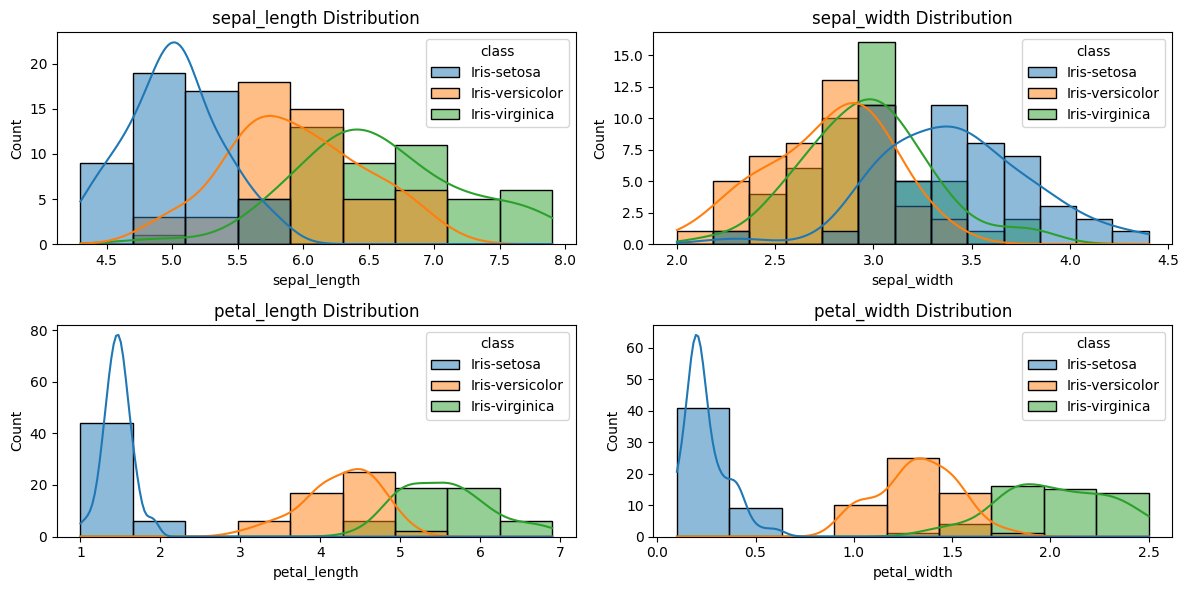

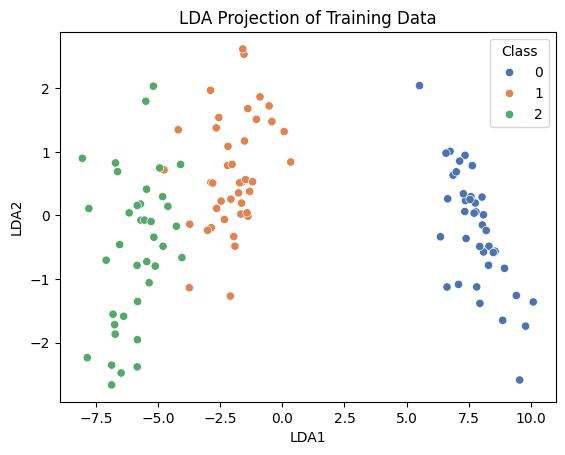


Accuracy: 0.97


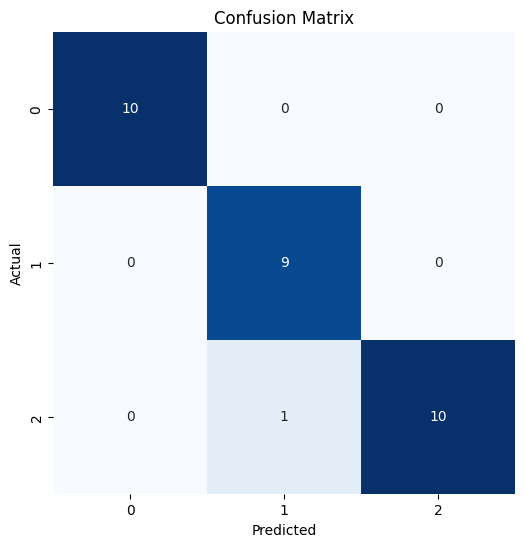

In [1]:
# ============================================
# Discriminant Analysis Example: Iris Dataset
# ============================================

# --------------------------------------------
# Step 1: Import required libraries
# --------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# --------------------------------------------
# Step 2: Load the dataset
# --------------------------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Define column names
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

# Read dataset
df = pd.read_csv(url, names=columns)

print("First five observations:")
print(df.head())

# --------------------------------------------
# Step 3: Prepare the data
# --------------------------------------------
# Separate features (X) and target variable (y)
X = df.iloc[:, 0:4].values
y = df.iloc[:, 4].values

# Convert categorical labels into numeric values
le = LabelEncoder()
y = le.fit_transform(y)

# --------------------------------------------
# Step 4: Explore the data
# --------------------------------------------
# Visualize distributions of each feature
plt.figure(figsize=(12, 6))

for i, feature in enumerate(columns[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=feature, hue='class', kde=True)
    plt.title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

# --------------------------------------------
# Step 5: Split data into training and testing sets
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# Step 6: Apply Linear Discriminant Analysis (LDA)
# --------------------------------------------
lda = LinearDiscriminantAnalysis(n_components=2)

# Fit LDA on training data and transform
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# --------------------------------------------
# Step 7: Visualize LDA components
# --------------------------------------------
lda_df = pd.DataFrame(X_train_lda, columns=['LDA1', 'LDA2'])
lda_df['Class'] = y_train

sns.scatterplot(
    data=lda_df,
    x='LDA1',
    y='LDA2',
    hue='Class',
    palette='deep'
)

plt.title("LDA Projection of Training Data")
plt.show()

# --------------------------------------------
# Step 8: Classification using Random Forest
# --------------------------------------------
model = RandomForestClassifier(max_depth=2, random_state=0)

model.fit(X_train_lda, y_train)

# Predict on test data
y_pred = model.predict(X_test_lda)

# --------------------------------------------
# Step 9: Evaluate model performance
# --------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    square=True,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
